# Case study：Survival（FeatureSetA + CatBoost）

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

PROJECT_ROOT: Path | None = None

MODEL_ID = "Survival_cand_16_CatBoost_binary_classification"


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "save" / "published_models").is_dir():
            return d
    raise FileNotFoundError(
        "Cannot find save/published_models. Please run in final or its subdirectory, or set PROJECT_ROOT."
    )


ROOT = PROJECT_ROOT or find_project_root()
MODEL_DIR = ROOT / "save" / "published_models" / MODEL_ID

for name, p in [("model.joblib", MODEL_DIR / "model.joblib"), ("metadata.json", MODEL_DIR / "metadata.json")]:
    if not p.is_file():
        raise FileNotFoundError(f"Missing {name}: {p}. Please publish the model in save/1.ipynb first.")

In [2]:
pipe = joblib.load(MODEL_DIR / "model.joblib")

with open(MODEL_DIR / "metadata.json", encoding="utf-8") as f:
    metadata: dict[str, Any] = json.load(f)

FEATURE_ORDER: list[str] = list(metadata["feature_order"])

bg_path = MODEL_DIR / "shap_artifacts" / "background_raw.parquet"
if not bg_path.is_file():
    raise FileNotFoundError(f"Missing SHAP background set: {bg_path}")

background_df = pd.read_parquet(bg_path)
missing_bg = [c for c in FEATURE_ORDER if c not in background_df.columns]
if missing_bg:
    raise ValueError(f"Background set missing columns: {missing_bg}")
background_df = background_df[FEATURE_ORDER].copy()

imputer = pipe.named_steps["imputer"]
clf = pipe.named_steps["clf"]

X_bg = np.asarray(imputer.transform(background_df), dtype=float)

print("feature number:", len(FEATURE_ORDER), "| algorithm:", metadata.get("algorithm"), "| task:", metadata.get("task_type"))

feature number: 28 | algorithm: CatBoost | task: binary_classification


In [76]:
# -----------------------------
# feature selection
# -----------------------------
def feature_selection(df, target):

    # Medication features (fixed as input, must be included for non-resistance tasks)
    polyType_cols = ['colistin_cms_daily_freq', 'polymyxin_b_daily_freq', 'colistin_sulfate_daily_freq']
    Combination_medication_cols = [
        'carbapenem_daily_dose', 'sulbactam_daily_dose', 'tigecycline_daily_dose',
        'minocycline_daily_dose', 'vancomycin_daily_dose', 'eravacycline_daily_dose',
        'aminoglycoside_daily_dose'
    ]
    medication_features = polyType_cols + Combination_medication_cols

    time_features = ['Pre_Hospital_Days', 'Pre_ICU_Days']
    base_cols = ['Age', 'Gender', 'BMI']

    comorb_cols = ['Diabetes Mellitus', 'Hypertension', 'Heart Disease', 'Stroke', 'Malignant Tumor',
        'Chronic Kidney Disease', 'Chronic Liver Disease', 'COPD', 'Comorb_other']
    # Derived feature (you already do this)
    df = df.copy()
    df[comorb_cols] = df[comorb_cols].fillna(0)
    df['Comorb_count'] = df[comorb_cols].sum(axis=1)
    comorb_cols = comorb_cols + ['Comorb_count']

    immuno_cols = ['Use immunosuppressive agents', 'Neutrophil Reduction', 'HIV/AIDS',
        'Post-Transplant Status', 'Chemotherapy/Radiation', 'immuno_Other']

    support_cols = ['Resp_support', 'Oxygen_concentration']

    pre_lab_cols = ['WBC', 'N_percent', 'L_count', 'PLT', 'CRP1', 'PCT1', 'D-d', 'Cr_baseline', 'eGFR1', 'RRT', 'ALT', 'AST', 'TB', 'ALB']
    # dynamic_lab_cols = ['PCT2', 'CRP2', 'Cr1', 'eGFR2', 'Cr2', 'eGFR3']
    dynamic_lab_cols = []
    lab_cols = pre_lab_cols + dynamic_lab_cols

    infection_cols = ['Infection_HAP', 'Infection_VAP']
    Coinfection_cols = ['Coinfection_G_Pos', 'Coinfection_G_Neg', 'Coinfection_Fungi']
    df[Coinfection_cols] = df[Coinfection_cols].fillna(0).astype(int)
    infection_cols = infection_cols + Coinfection_cols

    # ===== RSI mapping (R/I=1, S=0) =====
    resistance_features = ['resistance_SXT', 'resistance_KAN', 'resistance_MIN', 'resistance_TGC', 'resistance_CFP-SUL', 'resistance_TOB']
    mapping = {'R': 1, 'I': 1, 'S': 0}

    for c in resistance_features:
        if c in df.columns:
            s = df[c].astype(str).str.strip().str.upper()
            df[c] = pd.to_numeric(s.map(mapping), errors="coerce")

    # Only these two groups are collapsed in SHAP ranking / group enumeration
    group_defs = {
        "Comorbidity": [c for c in comorb_cols if c in df.columns],
        "Immunosuppression": [c for c in immuno_cols if c in df.columns],
    }

    if target == 'Target_Polymyxin':
        feature_cols = base_cols + time_features + comorb_cols + immuno_cols + support_cols + pre_lab_cols
        include_med = False
    else:
        feature_cols = (
            base_cols + comorb_cols + immuno_cols + support_cols +
            lab_cols + infection_cols + resistance_features +
            polyType_cols + Combination_medication_cols
        )
        include_med = True

    # Keep only existing columns (robust to missing cols in some tasks/files)
    feature_cols = [c for c in feature_cols if c in df.columns]

    return feature_cols, df, medication_features, group_defs, include_med

In [77]:
def get_medication_features():
    polyType_cols = ['colistin_cms_daily_freq', 'polymyxin_b_daily_freq', 'colistin_sulfate_daily_freq']
    Combination_medication_cols = [
        'carbapenem_daily_dose', 'sulbactam_daily_dose', 'tigecycline_daily_dose',
        'minocycline_daily_dose', 'vancomycin_daily_dose', 'eravacycline_daily_dose',
        'aminoglycoside_daily_dose'
    ]
    return polyType_cols + Combination_medication_cols


def expand_featureset(featureset, available_cols, group_defs):
    expanded = []
    for f in featureset:
        if f in group_defs:
            expanded.extend([c for c in group_defs[f] if c in available_cols])
        elif f in available_cols:
            expanded.append(f)
    return list(dict.fromkeys(expanded))


# ===== Step 1: X_train_sub, X_external_sub =====
def get_featureset_subset(X_train, X_external, featureset, group_defs, verbose=True):
    medication_features = get_medication_features()
    featureset_expanded = expand_featureset(featureset, X_train.columns, group_defs)
    cols_best = medication_features + [c for c in featureset_expanded if c in X_train.columns]

    X_train_sub = X_train[cols_best].copy()
    X_external_sub = X_external[cols_best].copy()

    if verbose:
        print(f"Step 1 - Feature set ({len(cols_best)} cols): {cols_best}\n")
    return X_train_sub, X_external_sub, cols_best


In [ ]:
import sys

TRAINSET_PATH='../../datasets/train_set.csv'
EXTERNAL_PATH='../../datasets/external-1.csv'
COHORT_ENCODING = "gbk"
TARGET = "Survival"

FEATURESET_CAND_16 = [
    "PLT",
    "eGFR1",
    "Comorbidity",
    "PCT1",
    "Age",
    "ALB",
    "N_percent",
    "Oxygen_concentration",
    "Cr_baseline",
]

train_df = pd.read_csv(TRAINSET_PATH, encoding=COHORT_ENCODING)
external_df = pd.read_csv(EXTERNAL_PATH, encoding=COHORT_ENCODING)

train_df = train_df[train_df[TARGET].notna()].copy()
train_df[TARGET] = train_df[TARGET].astype(int)
external_df = external_df[external_df[TARGET].notna()].copy()
external_df[TARGET] = external_df[TARGET].astype(int)

feature_cols, train_df, _, group_defs, _ = feature_selection(train_df, TARGET)
_, external_df, _, _, _ = feature_selection(external_df, TARGET)

X_train = train_df[feature_cols]

cols_common = [c for c in feature_cols if c in external_df.columns]
cols_missing = [c for c in feature_cols if c not in external_df.columns]
if cols_missing:
    print("Warn: Missing columns in the external queue will be filled with the median values of columns in the training set:", cols_missing)

X_external = external_df[cols_common].copy()
for c in cols_missing:
    X_external[c] = X_train[c].median()
X_external = X_external[feature_cols]

_, _, cols_best = get_featureset_subset(
    X_train, X_external, FEATURESET_CAND_16, group_defs, verbose=True
)
X_external_sub = X_external[cols_best].copy()

if set(cols_best) != set(FEATURE_ORDER):
    raise ValueError(
        "The feature columns are inconsistent with the released model.\n"
        f"  Only present in cols_best: {set(cols_best) - set(FEATURE_ORDER)}\n"
        f"  Only present in FEATURE_ORDER: {set(FEATURE_ORDER) - set(cols_best)}"
    )
X_external_sub = X_external_sub[FEATURE_ORDER]

thresh = float(metadata.get("threshold", 0.5))
pos_class = int(metadata.get("positive_class", 1))

proba = pipe.predict_proba(X_external_sub)[:, pos_class]
pred_label_arr = (proba >= thresh).astype(int)
y_true = external_df.loc[X_external_sub.index, TARGET].astype(int).to_numpy()

cohort_pred = pd.DataFrame(
    {
        "dataset_row_index": X_external_sub.index.to_numpy(),
        f"P_{TARGET}_class_{pos_class}": proba,
        "pred_label": pred_label_arr,
        "true_label": y_true,
    }
)


out_csv = f"results/{MODEL_ID}_new_cohort_predictions1.csv"
cohort_pred.to_csv(out_csv, index=False, encoding="utf-8-sig")
# print("rows:", len(cohort_pred), "| Saved:", out_csv.resolve())

try:
    display(cohort_pred.head(15))
except NameError:
    print(cohort_pred.head(15).to_string())

Step 1 - Feature set (28 cols): ['colistin_cms_daily_freq', 'polymyxin_b_daily_freq', 'colistin_sulfate_daily_freq', 'carbapenem_daily_dose', 'sulbactam_daily_dose', 'tigecycline_daily_dose', 'minocycline_daily_dose', 'vancomycin_daily_dose', 'eravacycline_daily_dose', 'aminoglycoside_daily_dose', 'PLT', 'eGFR1', 'Diabetes Mellitus', 'Hypertension', 'Heart Disease', 'Stroke', 'Malignant Tumor', 'Chronic Kidney Disease', 'Chronic Liver Disease', 'COPD', 'Comorb_other', 'Comorb_count', 'PCT1', 'Age', 'ALB', 'N_percent', 'Oxygen_concentration', 'Cr_baseline']



,dataset_row_index,P_Survival_class_1,pred_label,true_label
0,0,0.849373,1,1
1,1,0.972313,1,1
2,2,0.249659,0,1
3,3,0.792139,1,1
4,4,0.677015,1,1
5,5,0.897041,1,1
6,6,0.841476,1,1
7,7,0.885939,1,1
8,8,0.894206,1,1
9,9,0.829496,1,1


## SHAP：waterfall and force

In [ ]:
from typing import Any, Iterable
from pathlib import Path

import matplotlib.text as mtext
import sys

_e1 = ROOT / "experiments" / "external-1"
if str(_e1.resolve()) not in sys.path:
    sys.path.insert(0, str(_e1.resolve()))
from shap_waterfall_other_last import waterfall as _waterfall_other_last


def plot_shap_waterfall_and_force(
    pipe: Any,
    X_bg: np.ndarray,
    feature_order: list[str],
    metadata: dict[str, Any],
    case_df: pd.DataFrame,
    *,
    explainer: Any | None = None,
    top_k: int = 10,
    sample_label: str | None = None,
    show: bool = True,
    save_path: str | Path | None = None,
    save_dpi: int = 300,
) -> None:
    if len(case_df) != 1:
        raise ValueError("case_df must have exactly one row. Please use plot_shap_waterfall_and_force_many for multiple rows.")

    imputer = pipe.named_steps["imputer"]
    clf = pipe.named_steps["clf"]
    if explainer is None:
        explainer = shap.TreeExplainer(clf, data=X_bg, model_output="probability")

    case_df = case_df.reindex(columns=feature_order)
    X_case = np.asarray(imputer.transform(case_df), dtype=float)
    sv = explainer(X_case)

    pos_idx = int(metadata.get("positive_class", 1))
    vals = np.asarray(sv.values)

    if vals.ndim == 3 and vals.shape[-1] >= 2:
        slice_vals = vals[:, :, pos_idx]
        b = np.asarray(sv.base_values)
        if b.ndim == 2:
            sliced_base = b[:, pos_idx]
        else:
            sliced_base = np.array([float(np.ravel(b)[pos_idx])])
        sv_plot = shap.Explanation(
            slice_vals,
            sliced_base,
            sv.data,
            feature_names=list(feature_order),
        )
    else:
        sv_plot = sv

    base = float(np.ravel(np.asarray(sv_plot.base_values))[0])
    shap_arr = np.asarray(sv_plot.values)
    shap_vals = np.ravel(shap_arr[0]) if shap_arr.ndim >= 2 else np.ravel(shap_arr)
    feat_row = case_df.iloc[0].reindex(feature_order)

    order = np.argsort(-np.abs(shap_vals))
    n_feat = len(feature_order)
    k = min(top_k, n_feat)
    top_idx = order[:k]
    rest_idx = order[k:]

    names_top = [feature_order[int(i)] for i in top_idx]
    vals_top = shap_vals[top_idx].astype(float, copy=False)
    disp_top = np.array([pd.to_numeric(feat_row[nm], errors="coerce") for nm in names_top], dtype=float)

    if rest_idx.size > 0:
        other_shap = float(shap_vals[rest_idx].sum())
        other_name = f"{int(rest_idx.size)} other features"
        wf_names = names_top + [other_name]
        wf_shap = np.concatenate([vals_top, np.array([other_shap], dtype=float)])
        wf_disp = np.concatenate([disp_top, np.array([np.nan], dtype=float)])
    else:
        wf_names = names_top
        wf_shap = vals_top
        wf_disp = disp_top

    wf_exp = shap.Explanation(
        values=wf_shap.reshape(1, -1),
        base_values=np.array([base], dtype=float),
        data=wf_disp.reshape(1, -1),
        feature_names=wf_names,
    )

    plt.figure()
    if sample_label:
        plt.suptitle(sample_label, y=1.02, fontsize=12)
    _waterfall_other_last(wf_exp[0], max_display=max(25, len(wf_names) + 2), show=False)
    plt.tight_layout()

    _wf_ax = plt.gca()
    _fig = plt.gcf()
    _fig.canvas.draw()
    _ticks = list(_wf_ax.get_yticks())
    _labels = [lbl.get_text() for lbl in _wf_ax.get_yticklabels()]
    _fixed: list[str] = []
    for s in _labels:
        if s and ("other features" in s.lower()) and ("=" in s):
            _fixed.append(s.split("=", 1)[-1].strip())
        else:
            _fixed.append(s)
    if len(_fixed) == len(_ticks):
        _wf_ax.set_yticks(_ticks)
        _wf_ax.set_yticklabels(_fixed, fontsize=13)
    else:
        for _tick, _s in zip(_wf_ax.get_yticklabels(), _fixed):
            _tick.set_text(_s)
    for _ch in list(_wf_ax.get_children()):
        if isinstance(_ch, mtext.Text):
            _tx = _ch.get_text().strip()
            if _tx and ("other features" in _tx.lower()) and ("=" in _tx):
                _ch.set_text(_tx.split("=", 1)[-1].strip())
    _fig.canvas.draw_idle()

    if save_path is None:
        _case_row = globals().get("CASE_ROW", None)
        if _case_row is not None:
            save_path = ROOT / "plot" / "pics" / "case_study" / f"{_case_row}.png"

    if save_path is not None:
        out = Path(save_path)
        out.parent.mkdir(parents=True, exist_ok=True)
        _fig.savefig(out, dpi=save_dpi, bbox_inches="tight")
        print(f"waterfall saved to: {out.resolve()}")

    if show:
        plt.show()
    else:
        plt.close(_fig)


def plot_shap_waterfall_and_force_many(
    pipe: Any,
    X_bg: np.ndarray,
    feature_order: list[str],
    metadata: dict[str, Any],
    cases_df: pd.DataFrame,
    *,
    row_indices: Iterable[int] | None = None,
    top_k: int = 10,
    show: bool = True,
    save_dir: str | Path | None = None,
) -> None:
    clf = pipe.named_steps["clf"]
    explainer = shap.TreeExplainer(clf, data=X_bg, model_output="probability")
    df = cases_df.reindex(columns=feature_order)
    idxs = list(row_indices) if row_indices is not None else range(len(df))
    out_dir = Path(save_dir) if save_dir is not None else None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)

    for i in idxs:
        row_id = df.index[int(i)]
        out_path = None if out_dir is None else (out_dir / f"case_{row_id}.png")
        plot_shap_waterfall_and_force(
            pipe,
            X_bg,
            feature_order,
            metadata,
            df.iloc[[int(i)]],
            explainer=explainer,
            top_k=top_k,
            sample_label=f"Case dataset_row_index={row_id}",
            show=show,
            save_path=out_path,
        )

survival

waterfall saved to: C:\Users\cccccxw\Desktop\STARR0226\final\plot\pics\case_study\103.png


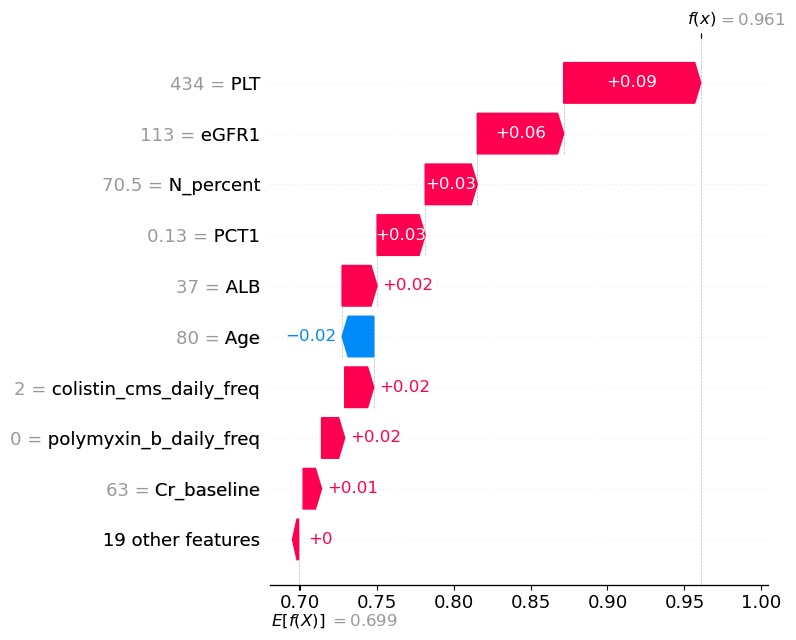

In [ ]:
CASE_CSV = EXTERNAL_PATH
CASE_ROW = 103
raw = pd.read_csv(CASE_CSV, encoding="gbk")
case_df = raw.iloc[[CASE_ROW]].reindex(columns=FEATURE_ORDER)
plot_shap_waterfall_and_force(
    pipe,
    X_bg,
    FEATURE_ORDER,
    metadata,
    case_df,
    top_k=9,
    sample_label=None,
    show=True,
)

death

waterfall saved to: C:\Users\cccccxw\Desktop\STARR0226\final\plot\pics\case_study\19.png


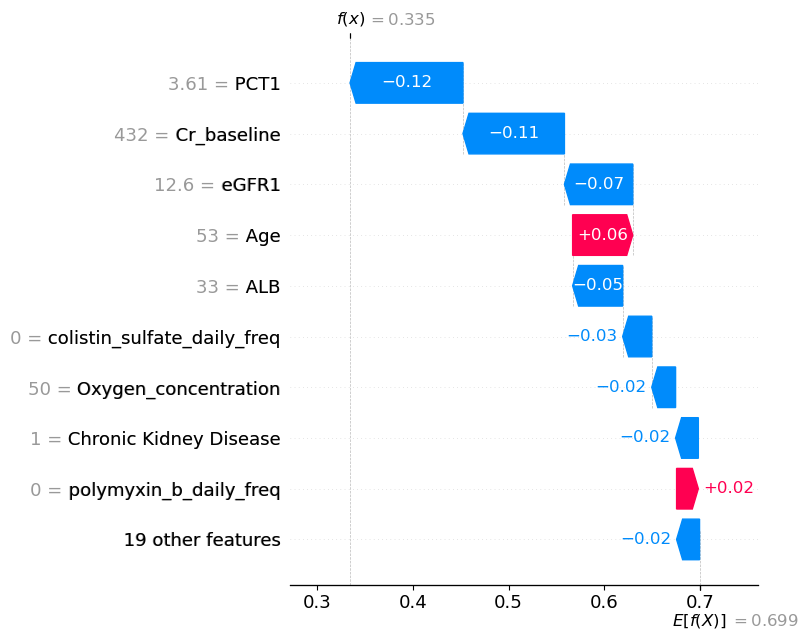

In [ ]:
CASE_CSV = EXTERNAL_PATH
CASE_ROW = 19
raw = pd.read_csv(CASE_CSV, encoding="gbk")
case_df = raw.iloc[[CASE_ROW]].reindex(columns=FEATURE_ORDER)
plot_shap_waterfall_and_force(
    pipe,
    X_bg,
    FEATURE_ORDER,
    metadata,
    case_df,
    top_k=9,
    sample_label=None,
    show=True,
)